In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az

In [2]:
data = get_data()
config, config_str = get_hmc_config()
colors = plt.cm.viridis(np.linspace(0, 1, config["nch"]))

In [3]:
samples = np.load(f"../../../../output/age_depth_unified/samples_{config_str}.npy")
energy_values = np.load(f"../../../../output/age_depth_unified/energy_values_{config_str}.npy")
bias_values = np.load(f"../../../../output/age_depth_unified/bias_values_{config_str}.npy")
resampled_samples = np.load(f"../../../../output/age_depth_unified/resampsamp_{config_str}.npy")

In [4]:
print(np.shape(resampled_samples))

(4, 9990, 10)


In [5]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

In [6]:
print(energy_values)

[[ -5.36098359  -4.97351806   5.66877514 ...  31.34516965  29.70963829
   31.24502587]
 [ 26.19138619   4.25804502  -3.07277611 ...  28.92845911  31.45611164
   33.59938492]
 [ 58.75686352  61.54662568  57.5660371  ...  97.67750585  96.97024785
  100.31696881]
 [ 29.98517515  15.55796978   0.16538799 ...  31.00370973  28.59821106
   31.66265646]]


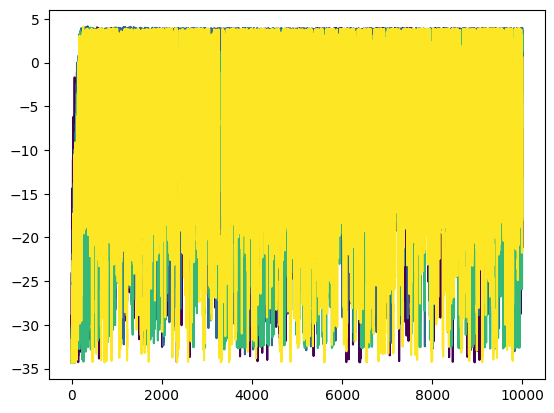

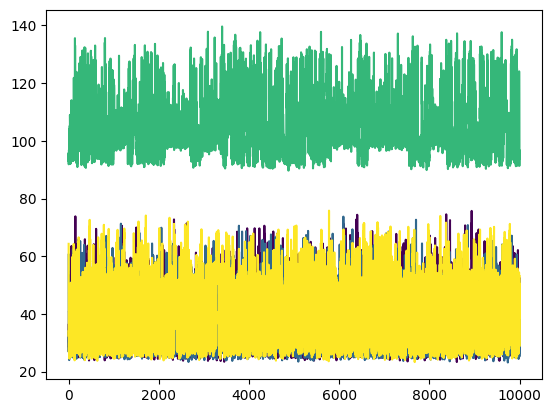

In [7]:
plt.figure()
for i in range(config["nch"]):
    plt.plot(bias_values[i,:], color = colors[i])
plt.show()

plt.figure()
for i in range(config["nch"]):
    plt.plot(energy_values[i,:] - bias_values[i,:], color = colors[i])
plt.show()


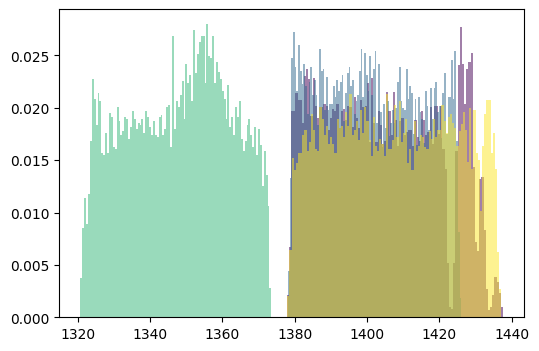

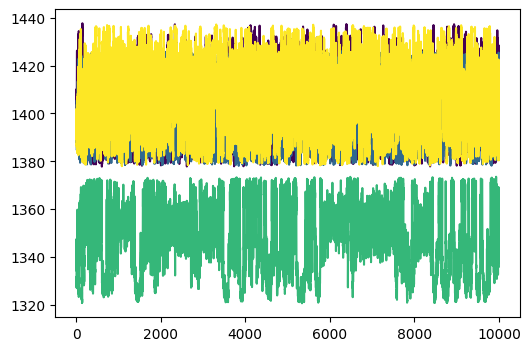

In [8]:
CV_values = data["theta"] - config["dc"] * np.sum(samples[:, :, :config["pidx"]], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.plot(CV_values[i, :], color = colors[i], label = f"chain {i}")
plt.show()

In [9]:
resampled_samples = resampled_samples[:,::1000,:]

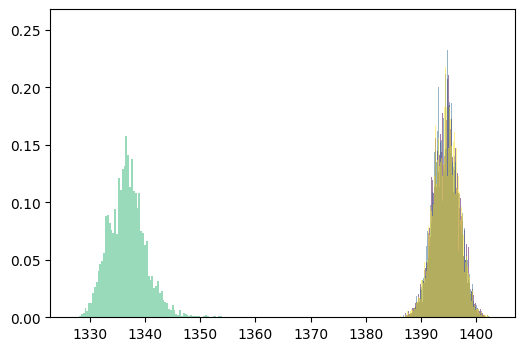

In [9]:
CV_values = data["theta"] - config["dc"] * np.sum(resampled_samples[:, :, :config["pidx"]], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

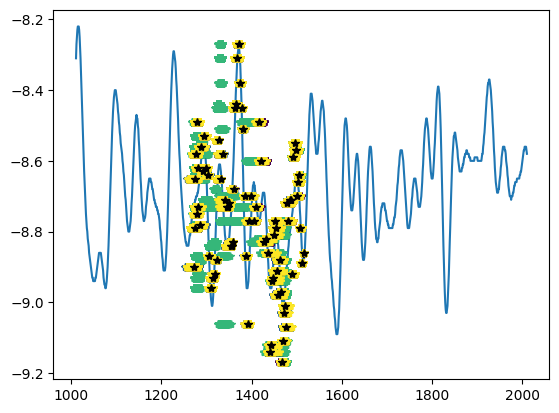

In [10]:
indices = []
for i in range(len(data["d18O_depths"])):
    index = get_index(config["N"], config["cs"], data["d18O_depths"], i)
    indices.append(index)

plt.figure()
plt.plot(data["d18O_reference_times"], data["d18O_reference"])
for i in range(config["nch"]):
    variables = resampled_samples[i,:,:]
    for j in range(len(variables)):
        d18O_ages = expected_ages(config["N"], config["dc"], config["cs"], data["theta"], len(data["d18O_depths"]), data["d18O_depths"], variables[j,:], indices)
        plt.plot(d18O_ages, data["d18O"], '*', color = colors[i])

plt.plot(data["true_ages_D18O"], data["d18O"], '*', color = "k")
plt.show()

In [11]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(resampled_samples)
summary = az.summary(idata, round_to=2)
print(summary)

       mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x[0]  10.08   1.07    8.07    12.02       0.01     0.00  38637.93  39494.17   
x[1]  11.21   1.85    7.68    14.58       0.01     0.01  39210.99  39128.29   
x[2]   8.14   2.55    3.67    13.47       0.08     0.01   1389.79  35454.51   
x[3]  10.39   2.62    6.01    15.75       0.02     0.05   1009.39  33663.69   
x[4]  30.13  12.66   19.75    53.22       6.24     3.63      7.06     25.08   
x[5]  10.93   4.83    1.25    16.83       2.25     1.22      7.07     25.11   
x[6]  13.49   2.18    9.44    17.63       0.01     0.09  35087.35  19941.23   
x[7]  13.82   2.61    9.27    18.73       0.63     0.01     17.02     86.69   
x[8]  11.41   6.31    0.02    17.92       3.02     1.59      7.06     24.84   
x[9]   5.04   3.48    0.15    11.46       0.68     0.05     24.21    222.15   

      r_hat  
x[0]   1.00  
x[1]   1.00  
x[2]   1.01  
x[3]   1.01  
x[4]   1.53  
x[5]   1.52  
x[6]   1.02  
x[7]   1.15  
x[8]